In [11]:
import particles
from sir_PMCMC import ChainBinomialModel
from sir_PMCMC import ScalarStructDist
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb

from particles import distributions as dists
from particles import state_space_models as ssm
from particles.collectors import Moments
from particles import mcmc
from collections import OrderedDict


# Simulate SIR epidemic in Particles

In [2]:
model = ChainBinomialModel(N = 10000, beta = 0.3, gamma = 0.1, rho = 0.25, phi = 2, n_i =10)
x, y = model.simulate(100)

# Plot SIR epidemic progression in Matplotlib

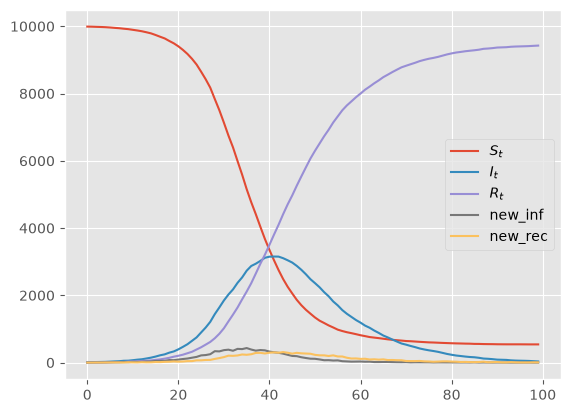

In [3]:
# Plot count of new infections, new recoveries, susceptibles, infectious, and removed
plt.style.use('ggplot')
plt.plot([xt['S'] for xt in x], label=r'$S_t$')
plt.plot([xt['I'] for xt in x], label=r'$I_t$')
plt.plot([xt['R'] for xt in x], label=r'$R_t$')
plt.plot([xt['new_inf'] for xt in x], label='new_inf')
plt.plot([xt['new_rec'] for xt in x], label='new_rec')
plt.legend()

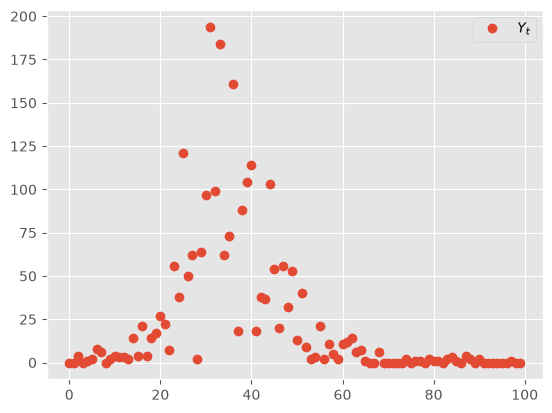

In [4]:
# Plot the observation model
plt.style.use('ggplot')
plt.plot(y, label=r'$Y_t$', linestyle='', marker='o')

plt.legend()

# DataFrames & csv files

In [5]:
simulation_df = pd.DataFrame(np.concatenate(x))
print(simulation_df)

    new_inf  new_rec       S     I       R
0       0.0      0.0  9990.0  10.0     0.0
1       3.0      0.0  9987.0  13.0     0.0
2       5.0      2.0  9982.0  16.0     2.0
3       4.0      1.0  9978.0  19.0     3.0
4       6.0      3.0  9972.0  22.0     6.0
..      ...      ...     ...   ...     ...
95      0.0      4.0   543.0  56.0  9401.0
96      1.0      4.0   542.0  53.0  9405.0
97      1.0      5.0   541.0  49.0  9410.0
98      0.0      8.0   541.0  41.0  9418.0
99      0.0      7.0   541.0  34.0  9425.0

[100 rows x 5 columns]


In [6]:
observation_df = pd.DataFrame(np.concatenate(y))
observation_df = observation_df.rename(columns={0: 'observations'})
print(observation_df)

    observations
0              0
1              0
2              4
3              0
4              1
..           ...
95             0
96             0
97             1
98             0
99             0

[100 rows x 1 columns]


In [7]:
# Save to csv - commented out until needed

"""simulation_df.to_csv('sir_simulation.csv', index=False)
observation_df.to_csv('sir_observation.csv', index=False)"""

"simulation_df.to_csv('sir_simulation.csv', index=False)\nobservation_df.to_csv('sir_observation.csv', index=False)"

# Sequential Monte Carlo

In [8]:
fk = ssm.Bootstrap(ssm=model, data=y)
alg = particles.SMC(fk=fk, 
                    N=5000,
                    resampling = 'systematic', 
                    verbose=True)
alg.run()

t=0: resample:False, ESS (end of iter)=5000.00
t=1: resample:False, ESS (end of iter)=4574.35
t=2: resample:False, ESS (end of iter)=2725.08
t=3: resample:False, ESS (end of iter)=2501.39
t=4: resample:False, ESS (end of iter)=2430.50
t=5: resample:True, ESS (end of iter)=4791.33
t=6: resample:False, ESS (end of iter)=2377.74
t=7: resample:True, ESS (end of iter)=4220.22
t=8: resample:False, ESS (end of iter)=3930.32
t=9: resample:False, ESS (end of iter)=3649.12
t=10: resample:False, ESS (end of iter)=3569.63
t=11: resample:False, ESS (end of iter)=3249.02
t=12: resample:False, ESS (end of iter)=2801.22
t=13: resample:False, ESS (end of iter)=2115.66
t=14: resample:True, ESS (end of iter)=4526.52
t=15: resample:False, ESS (end of iter)=4630.08
t=16: resample:False, ESS (end of iter)=4159.51
t=17: resample:False, ESS (end of iter)=4242.69
t=18: resample:False, ESS (end of iter)=4169.82
t=19: resample:False, ESS (end of iter)=4084.12
t=20: resample:False, ESS (end of iter)=4004.05
t=21:

# Priors

In [17]:
prior_dict = {'beta': dists.Uniform(a=0, b=0.5),
              'gamma': dists.Uniform(a= 0, b= 0.5)}  # Uniform distribution because the prior is uninformative

my_prior = ScalarStructDist(prior_dict)      # need this because 'dict' object has no attribute 'dtype' but StructDist does

# PMMH

In [19]:
pmmh = mcmc.PMMH(ssm_cls= ChainBinomialModel, prior = my_prior, data=y, Nx=10000, niter=5000, adaptive=True)
pmmh.run()

/var/folders/78/7v9nz15x7059dykx93846qzm0000gn/T/ipykernel_69205/4062688341.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(pmmh.chain.theta[param][burnin:])
/var/folders/78/7v9nz15x7059dykx93846qzm0000gn/T/ipykernel_69205/4062688341.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(pmmh.cha

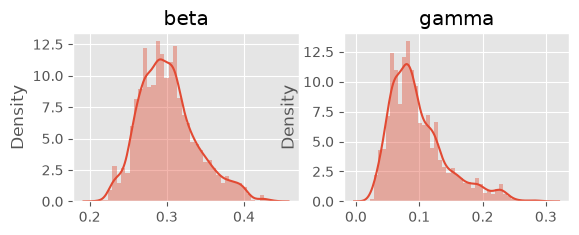

In [20]:
# plot the marginals
burnin = 100
for i, param in enumerate(prior_dict.keys()):
    plt.subplot(2, 2, i+1)
    sb.distplot(pmmh.chain.theta[param][burnin:])
    plt.title(param)

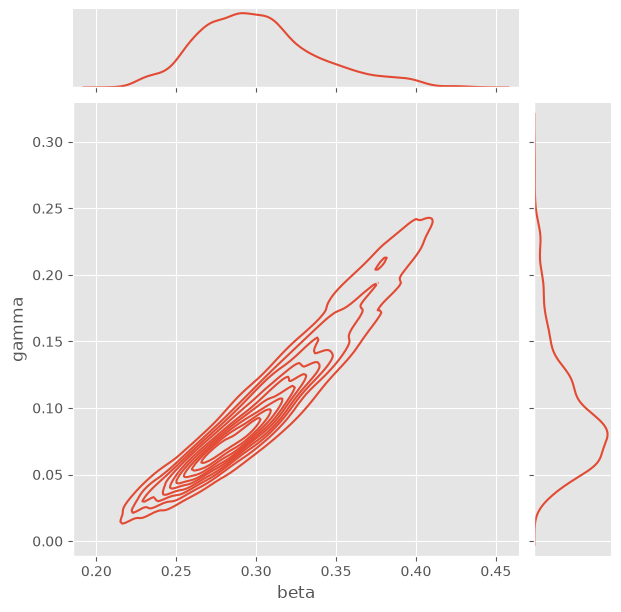

In [21]:
beta_density = pmmh.chain.theta['beta'][burnin:]
gamma_density = pmmh.chain.theta['gamma'][burnin:]
sb.jointplot(x = beta_density, y = gamma_density, kind = 'kde')
plt.xlabel('beta')
plt.ylabel('gamma')
plt.show()